# NB30 - rolling typical profitability and drawdown diagnostics

Based on the frozen rolling-track inputs used by [NB25](25-research-rolling-metrics-controls.ipynb).
This is a vault-level diagnostic, not a portfolio optimiser. It asks whether the typical magnitude
of recent rolling returns contains information beyond ordinary growth, profitable-window share,
Sharpe-like return/risk and volatility, and whether a separate drawdown path measure adds anything.

The experiment was specified in [rolling-typical-profitability-plan-01.md](rolling-typical-profitability-plan-01.md)
and reviewed with Grok 4.6 at xhigh reasoning effort. Earlier evidence is summarised in that plan:
NB09 already tested profitable rolling-window frequency; NB19/NB20 measured StratWise-like weekly
path features and found no robust portfolio screen; NB24's monthly score saturated; NB28 found
risk persistence more readily than return persistence; NB32 and NB90 rejected related hard stability
portfolios. No new monthly gate, long-history admission rule, blacklist or allocation formula is
introduced here.

## Key new insights and what did we learn from this experiment?

The new lower-quartile rolling return is the only clear exploratory lead. `Q25_7_60` has the best
return rank IC (mean daily Spearman rho 0.112 for the 30-day label and 0.141 for the 60-day label),
and its top quintile beats the rest by about 2.0 and 3.3 percentage points respectively. In paired
date comparisons its return rank is ahead of growth, profitable-window share and Sharpe-like rank at
the 60-day horizon, although it is behind inverse volatility. These are small, overlapping-sample
effects rather than a validated trading signal. The median rolling return is weak (best return IC
about 0.031) and usually does not improve the top-quintile return.

The lower quartile is more useful as a downside diagnostic than as a complete selector: `Q25_7_60`
has a drawdown IC of about 0.52 after controlling for Sharpe-like rank and positive-window share,
while the median adds little. The strong inverse-volatility and drawdown associations confirm that
future loss depth is easier to forecast than future return. No portfolio backtest was run, so this
experiment does not establish a 20% CAGR, a Sharpe improvement, or that the features select StratWise
consistently.

## Summary of results

The causal panel contains 92,008 rows across 405 daily decision dates, 530 vaults and 602 observed
addresses. The opportunity set has 81,095 rows and 489 vaults with finite rolling scores. It includes
26,443 sparse rows; seven rows have only one seven-day event and 703 have only one fourteen-day event.
Return rank statistics use 379 dates for the 30-day label and 349 for the 60-day label; drawdown
statistics use 219 and 196 dates. StratWise has 41 opportunity rows in the archive and Systemic L/S
Grids has 391, so they are descriptive examples rather than well-powered comparisons.

Results are written to `_artifacts-rolling-typical-profitability/` and rendered below after execution.

## Robustness of results

The panel uses overlapping daily decision dates and reused research dates. Descriptive block-bootstrap
intervals are reported without family-wise significance or an independent holdout claim. Sparse and
young cohorts are reported separately; missing features never become favourable zero-risk values. The
notebook also reruns the ranking summaries after correcting the percentile direction so higher-is-
better scores rank towards one. Results should therefore be treated as candidate diagnostics to test
in a later walk-forward portfolio simulation, not as a production formula.

In [1]:
from pathlib import Path
import hashlib
import json
import math
import platform
import time
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

PROJECT_DIR = Path.cwd() / "scratchpad/hyperliquid-ic" if (Path.cwd() / "scratchpad/hyperliquid-ic").exists() else Path.cwd()
REWRITE = PROJECT_DIR / "_artifacts-rewrite"
OUT = PROJECT_DIR / "_artifacts-rolling-typical-profitability"
OUT.mkdir(parents=True, exist_ok=True)

NOTEBOOK_NAME = "30-research-rolling-typical-profitability.ipynb"
PLAN_NAME = "rolling-typical-profitability-plan-01.md"
SPECS = [(7, 30), (14, 30), (7, 60), (14, 60)]
HORIZONS = (30, 60)
DECISION_START = pd.Timestamp("2025-07-31")
DECISION_END = pd.Timestamp("2026-09-08")
STALE_TOLERANCE_DAYS = 7.0
TVL_FLOOR = 7_500.0
GATE_FLOOR = -0.16
BOOTSTRAP_DRAWS = 200
BOOTSTRAP_BLOCK_DAYS = 60

OBS_PATH = REWRITE / "observations.parquet"
FEATURE_PATH = REWRITE / "features.parquet"
LABEL_PATH = REWRITE / "labels.parquet"
source_files = [OBS_PATH, FEATURE_PATH, LABEL_PATH, PROJECT_DIR / PLAN_NAME]
source_hashes = {
    str(path.relative_to(PROJECT_DIR)) if path.is_relative_to(PROJECT_DIR) else str(path): hashlib.sha256(path.read_bytes()).hexdigest()
    for path in source_files
    if path.exists() and path.is_file()
}

print({
    "notebook": NOTEBOOK_NAME,
    "python": platform.python_version(),
    "decision_range": (str(DECISION_START.date()), str(DECISION_END.date())),
    "feature_settings": SPECS,
    "forward_horizons": HORIZONS,
    "source_hashes": source_hashes,
}, flush=True)

{'notebook': '30-research-rolling-typical-profitability.ipynb', 'python': '3.14.3', 'decision_range': ('2025-07-31', '2026-09-08'), 'feature_settings': [(7, 30), (14, 30), (7, 60), (14, 60)], 'forward_horizons': (30, 60), 'source_hashes': {'_artifacts-rewrite/observations.parquet': '3e6aeb3aa274da4982f805a5f96de78d7fb61853f5e038b49920d55da30cbbaf', '_artifacts-rewrite/features.parquet': '1636f3c1cad0b8a33f690bc6db18a94527403e3e48cee34d8aab160402451c84', '_artifacts-rewrite/labels.parquet': '5edb078d662850eab4d4e7eb6ec64d66e712825b45239d9339315d5fefb34583', 'rolling-typical-profitability-plan-01.md': '0f001c7daa8f74f42ae264a234c5005d27a416429f63df4a6383202e60c3d3e5'}}


## Causal observed-mark helpers

The stored rewrite observations are raw marks, not a forward-filled daily series. We retain the
last mark per UTC day only to prevent multiple same-day polls from counting as multiple outcomes.
For a decision boundary `T`, marks on `T-1` are usable and marks on `T` or later are forbidden.
Rolling outcomes are represented by their ending mark inside `(T-W, T)`. Their starting mark is
the latest observed mark at or before the requested `h`-day boundary, with at most seven days of
start carry. The resulting log return is divided by its actual elapsed days before taking M or Q.

In [2]:
def normalise_timestamp(value):
    ts = pd.Timestamp(value)
    if ts.tzinfo is not None:
        ts = ts.tz_convert("UTC").tz_localize(None)
    return ts


def last_mark_per_day(group: pd.DataFrame) -> pd.DataFrame:
    g = group.copy()
    g["timestamp"] = pd.to_datetime(g["timestamp"]).map(normalise_timestamp)
    g = g.sort_values("timestamp")
    g["day"] = g["timestamp"].dt.normalize()
    g = g.drop_duplicates("day", keep="last")
    return g.set_index("day").sort_index()


def rolling_row(marks: pd.DataFrame, date: pd.Timestamp, h: int, w: int) -> dict:
    """Calculate a setting with NumPy indices to keep the full archive tractable."""
    boundary = np.datetime64(normalise_timestamp(date) + pd.Timedelta(days=1), "ns")
    days = marks.index.to_numpy(dtype="datetime64[ns]")
    prices = marks["share_price"].to_numpy(dtype=float)
    available_end = int(np.searchsorted(days, boundary, side="left") - 1)
    if available_end < 1 or (boundary - days[available_end]) / np.timedelta64(1, "D") > STALE_TOLERANCE_DAYS:
        return {"median_log_rate": np.nan, "lower_quartile_log_rate": np.nan, "positive_window_share": np.nan,
                "unique_event_count": 0, "largest_positive_share": np.nan, "largest_event_containment_share": np.nan,
                "exact_median_equals_q25": False, "history_span_days": np.nan, "path_marks": 0,
                "last_mark_day": pd.NaT, "last_mark_age_days": np.nan, "ordinary_growth_per_day": np.nan,
                "ordinary_growth_annualised": np.nan, "volatility": np.nan, "sharpe_like": np.nan,
                "mean_drawdown": np.nan, "current_drawdown": np.nan}
    end_floor = boundary - np.timedelta64(int(w), "D")
    end_indices = np.arange(np.searchsorted(days, end_floor, side="right"), available_end + 1)
    if len(end_indices) == 0:
        return {"median_log_rate": np.nan, "lower_quartile_log_rate": np.nan, "positive_window_share": np.nan,
                "unique_event_count": 0, "largest_positive_share": np.nan, "largest_event_containment_share": np.nan,
                "exact_median_equals_q25": False, "history_span_days": np.nan, "path_marks": 0,
                "last_mark_day": pd.NaT, "last_mark_age_days": np.nan, "ordinary_growth_per_day": np.nan,
                "ordinary_growth_annualised": np.nan, "volatility": np.nan, "sharpe_like": np.nan,
                "mean_drawdown": np.nan, "current_drawdown": np.nan}
    target_starts = days[end_indices] - np.timedelta64(int(h), "D")
    start_indices = np.searchsorted(days, target_starts, side="right") - 1
    carry_days = (target_starts - days[np.maximum(start_indices, 0)]) / np.timedelta64(1, "D")
    elapsed_days = (days[end_indices] - days[np.maximum(start_indices, 0)]) / np.timedelta64(1, "D")
    valid = (start_indices >= 0) & (carry_days <= STALE_TOLERANCE_DAYS) & (elapsed_days > 0)
    end_indices = end_indices[valid]
    start_indices = start_indices[valid]
    elapsed_days = elapsed_days[valid].astype(float)
    event_rates = np.log(prices[end_indices] / prices[start_indices]) / elapsed_days if len(end_indices) else np.array([], dtype=float)
    event_valid = np.isfinite(event_rates)
    rates = event_rates[event_valid]
    event_starts = start_indices[event_valid]
    event_ends = end_indices[event_valid]
    if len(rates):
        m = float(np.median(rates))
        q = float(np.quantile(rates, 0.25, method="linear"))
        p = float(np.mean(rates > 0))
        count = int(len(rates))
        positive = rates[rates > 0]
        max_gain_share = float(np.max(positive) / positive.sum()) if len(positive) and positive.sum() > 0 else np.nan
        largest_index = int(np.argmax(rates))
        largest_start = days[event_starts[largest_index]]
        largest_end = days[event_ends[largest_index]]
        largest_event_containment_share = float(np.mean((days[event_starts] <= largest_start) & (days[event_ends] >= largest_end)))
    else:
        m = q = p = max_gain_share = largest_event_containment_share = np.nan
        count = 0

    path_start = max(0, int(np.searchsorted(days, end_floor, side="right") - 1))
    path_indices = np.arange(path_start, available_end + 1)
    path_prices = prices[path_indices]
    path_days = days[path_indices]
    if len(path_indices) >= 2 and np.all(np.isfinite(path_prices)) and np.all(path_prices > 0):
        path_elapsed = (path_days[1:] - path_days[:-1]) / np.timedelta64(1, "D")
        path_log_returns = np.diff(np.log(path_prices))
        path_valid = np.isfinite(path_elapsed) & (path_elapsed > 0) & np.isfinite(path_log_returns)
        path_elapsed = path_elapsed[path_valid].astype(float)
        path_log_returns = path_log_returns[path_valid]
        span_days = float(path_elapsed.sum()) if len(path_elapsed) else np.nan
        growth_per_day = float(np.log(path_prices[-1] / path_prices[0]) / span_days) if np.isfinite(span_days) and span_days > 0 else np.nan
        residual = path_log_returns - growth_per_day * path_elapsed if np.isfinite(growth_per_day) else np.array([])
        volatility = float(np.sqrt(365.0 * np.sum(residual ** 2) / span_days)) if len(residual) >= 2 and span_days > 0 else np.nan
        sharpe_like = float(365.0 * growth_per_day / max(volatility, 0.05)) if np.isfinite(volatility) else np.nan
        running_max = np.maximum.accumulate(path_prices)
        dd = 1.0 - path_prices / running_max
        mean_drawdown = float(np.sum(dd[:-1][path_valid] * path_elapsed) / span_days) if np.isfinite(span_days) and span_days > 0 else np.nan
        current_drawdown = float(dd[-1])
    else:
        span_days = growth_per_day = volatility = sharpe_like = mean_drawdown = current_drawdown = np.nan
    return {
        "median_log_rate": m,
        "lower_quartile_log_rate": q,
        "positive_window_share": p,
        "unique_event_count": count,
        "largest_positive_share": max_gain_share,
        "largest_event_containment_share": largest_event_containment_share,
        "exact_median_equals_q25": bool(np.isfinite(m) and np.isfinite(q) and np.isclose(m, q)),
        "history_span_days": span_days,
        "path_marks": int(len(path_indices)),
        "last_mark_day": pd.Timestamp(days[available_end]),
        "last_mark_age_days": float((boundary - days[available_end]) / np.timedelta64(1, "D")),
        "ordinary_growth_per_day": growth_per_day,
        "ordinary_growth_annualised": 365.0 * growth_per_day if np.isfinite(growth_per_day) else np.nan,
        "volatility": volatility,
        "sharpe_like": sharpe_like,
        "mean_drawdown": mean_drawdown,
        "current_drawdown": current_drawdown,
    }

## Load the frozen panel and build rolling typical-return features

The feature panel is built before forward labels are joined. The opportunity set uses only historical
TVL, the common available-history return gate and mark freshness. A vault with no M/Q observation
remains an opportunity row with missing feature values; it is not silently removed from the universe.

In [3]:
observations = pd.read_parquet(OBS_PATH, columns=["address", "timestamp", "share_price", "total_assets", "is_fresh"])
observations["address"] = observations["address"].astype(str).str.lower()
observations["timestamp"] = pd.to_datetime(observations["timestamp"]).map(normalise_timestamp)
observations = observations.loc[observations.is_fresh & observations.share_price.notna() & observations.share_price.gt(0)].copy()
observations = observations.sort_values(["address", "timestamp"])
marks_by_address = {address: last_mark_per_day(group[["timestamp", "share_price"]]) for address, group in observations.groupby("address")}
print({"raw_observations": len(observations), "addresses": len(marks_by_address), "first_mark": str(observations.timestamp.min()), "last_mark": str(observations.timestamp.max())}, flush=True)

feature_columns = [
    "date", "address", "tvl_current", "last_observation_ts", "nav_age_days", "available_history_days",
    "incumbent_return_gate", "incumbent_score", "incumbent_inverse_vol", "eligible",
]
point = pd.read_parquet(FEATURE_PATH, columns=feature_columns)
point["address"] = point["address"].astype(str).str.lower()
point["date"] = pd.to_datetime(point["date"]).dt.normalize()
point = point.loc[point.date.between(DECISION_START, DECISION_END)].copy()
point["opportunity"] = (
    point["tvl_current"].ge(TVL_FLOOR)
    & point["incumbent_return_gate"].gt(GATE_FLOOR)
    & point["nav_age_days"].le(STALE_TOLERANCE_DAYS)
)
point["cadence"] = np.where(point["is_sparse_prediction"] if "is_sparse_prediction" in point else False, "sparse", "dense")

feature_rows = []
dates = pd.date_range(DECISION_START, DECISION_END, freq="D")
started = time.monotonic()
addresses = sorted(marks_by_address)
point_keys = set(zip(point["address"], point["date"]))
for i, address in enumerate(addresses):
    marks = marks_by_address[address]
    for date in dates:
        if (address, date) not in point_keys:
            continue
        base = {"date": date, "address": address}
        for h, w in SPECS:
            base.update({f"{k}_{h}_{w}": v for k, v in rolling_row(marks, date, h, w).items()})
        feature_rows.append(base)
    if (i + 1) % 50 == 0:
        remaining = (time.monotonic() - started) / (i + 1) * (len(addresses) - i - 1) / 60.0
        print(f"{i + 1}/{len(addresses)} addresses; estimated minutes remaining {remaining:.1f}", flush=True)

rolling = pd.DataFrame(feature_rows)
panel = point.merge(rolling, on=["date", "address"], how="left", validate="one_to_one")
labels = pd.read_parquet(LABEL_PATH)
labels["address"] = labels["address"].astype(str).str.lower()
labels["date"] = pd.to_datetime(labels["date"]).dt.normalize()
labels = labels.loc[labels.date.between(DECISION_START, DECISION_END)].copy()
for horizon in HORIZONS:
    panel[f"forward_return_{horizon}"] = np.expm1(labels.set_index(["date", "address"])[f"forward_log_growth_raw_{horizon}"].reindex(pd.MultiIndex.from_frame(panel[["date", "address"]])).to_numpy())
    panel[f"forward_drawdown_{horizon}"] = labels.set_index(["date", "address"])[f"forward_max_drawdown_{horizon}"].reindex(pd.MultiIndex.from_frame(panel[["date", "address"]])).to_numpy()
    panel[f"forward_actual_days_{horizon}"] = labels.set_index(["date", "address"])[f"actual_holding_days_{horizon}"].reindex(pd.MultiIndex.from_frame(panel[["date", "address"]])).to_numpy()

panel["age_cohort"] = pd.cut(panel["available_history_days"], [-np.inf, 30, 90, np.inf], labels=["<30d", "30-89d", ">=90d"])
panel["cadence"] = np.where(panel[[f"path_marks_{h}_{w}" for h, w in SPECS]].max(axis=1).fillna(0).lt(12), "sparse", "dense")
panel.to_parquet(OUT / "feature-label-panel.parquet", index=False)
print({"panel_rows": len(panel, ), "opportunity_rows": int(panel.opportunity.sum()), "dates": panel.date.nunique(), "feature_vaults": panel.address.nunique()}, flush=True)
display(panel.groupby("date").agg(rows=("address", "size"), opportunity=("opportunity", "sum")).head())

{'raw_observations': 487738, 'addresses': 602, 'first_mark': '2023-03-01 00:00:00', 'last_mark': '2026-09-13 13:50:25.069000'}


50/602 addresses; estimated minutes remaining 0.6


100/602 addresses; estimated minutes remaining 0.6


150/602 addresses; estimated minutes remaining 0.5


200/602 addresses; estimated minutes remaining 0.5


...

500/602 addresses; estimated minutes remaining 0.1


550/602 addresses; estimated minutes remaining 0.1


600/602 addresses; estimated minutes remaining 0.0


{'panel_rows': 92008, 'opportunity_rows': 81095, 'dates': 405, 'feature_vaults': 530}


,rows,opportunity
date,,
2025-07-31,124,99
2025-08-01,124,99
2025-08-02,124,99
2025-08-03,124,99
2025-08-04,124,99


## Coverage and reference-vault diagnostics

Ranks are later formed on the feature-available opportunity set. Coverage is retained by age and
cadence, including the two illustrative reference addresses where present in this frozen archive.

In [4]:
coverage_rows = []
for h, w in SPECS:
    score = f"median_log_rate_{h}_{w}"
    qscore = f"lower_quartile_log_rate_{h}_{w}"
    for label, series in [("median", panel[score]), ("lower_quartile", panel[qscore])]:
        d = panel.loc[panel.opportunity]
        coverage_rows.append({
            "feature": label, "horizon": h, "span": w,
            "opportunity_rows": len(d), "finite_rows": int(series.loc[d.index].notna().sum()),
            "finite_fraction": float(series.loc[d.index].notna().mean()),
            "finite_vaults": int(panel.loc[d.index].loc[series.loc[d.index].notna(), "address"].nunique()),
            "one_event_rows": int(panel.loc[d.index, f"unique_event_count_{h}_{w}"].eq(1).sum()),
            "sparse_rows": int(panel.loc[d.index, "cadence"].eq("sparse").sum()),
        })
coverage = pd.DataFrame(coverage_rows)
coverage.to_csv(OUT / "coverage.csv", index=False)
display(coverage)

reference_addresses = {
    "StratWise": "0x0ff219ac20596b457558341bc410bc7a08a1394c",
    "Systemic L/S Grids": "0x07fd993f0fa3a185f7207adccd29f7a87404689d",
}
reference_rows = []
for label, address in reference_addresses.items():
    subset = panel.loc[panel.address.eq(address)]
    if subset.empty:
        reference_rows.append({"reference": label, "address": address, "rows": 0, "first_date": pd.NaT, "last_date": pd.NaT})
    else:
        row = subset.sort_values("date").iloc[-1]
        reference_rows.append({"reference": label, "address": address, "rows": len(subset), "first_date": subset.date.min(), "last_date": subset.date.max(), "opportunity_rows": int(subset.opportunity.sum()), **{c: row[c] for c in [f"median_log_rate_{h}_{w}" for h, w in SPECS]}})
references = pd.DataFrame(reference_rows)
references.to_csv(OUT / "reference-vaults.csv", index=False)
display(references)

,feature,horizon,span,opportunity_rows,finite_rows,finite_fraction,finite_vaults,one_event_rows,sparse_rows
0,median,7,30,81095,81095,1.0,489,7,26443
1,lower_quartile,7,30,81095,81095,1.0,489,7,26443
2,median,14,30,81095,81095,1.0,489,703,26443
3,lower_quartile,14,30,81095,81095,1.0,489,703,26443
4,median,7,60,81095,81095,1.0,489,7,26443
5,lower_quartile,7,60,81095,81095,1.0,489,7,26443
6,median,14,60,81095,81095,1.0,489,703,26443
7,lower_quartile,14,60,81095,81095,1.0,489,703,26443


,reference,address,rows,first_date,last_date,opportunity_rows,median_log_rate_7_30,median_log_rate_14_30,median_log_rate_7_60,median_log_rate_14_60
0,StratWise,0x0ff219ac20596b457558341bc410bc7a08a1394c,54,2026-07-17,2026-09-08,41,0.000739,0.000915,0.000666,0.000795
1,Systemic L/S Grids,0x07fd993f0fa3a185f7207adccd29f7a87404689d,405,2025-07-31,2026-09-08,391,0.003519,0.005325,0.002865,0.004981


## Marginal ranking comparisons

The new scores are compared on identical historical opportunity rows against ordinary growth, positive
window share, Sharpe-like growth/risk and inverse volatility. Spearman values are averaged equally by
decision date. Top quintile membership is calculated before forward-label masking; a tied boundary
receives fractional membership rather than an address tie-break. A constant score is reported as
uninformative.

In [5]:
def rank_series(group: pd.DataFrame, column: str, higher_is_better: bool = True) -> pd.Series:
    values = group[column]
    # Percentile increases towards the desirable end of the signal.
    return values.rank(method="average", ascending=higher_is_better, pct=True)


def fractional_top_membership(values: pd.Series, fraction: float = 0.2) -> pd.Series:
    finite = values.notna()
    n = int(finite.sum())
    out = pd.Series(0.0, index=values.index)
    if n == 0:
        return out
    target = max(1.0, n * fraction)
    ranks = values.loc[finite].rank(method="average", ascending=False)
    above = ranks < target
    boundary = ranks.eq(ranks[ranks <= target].max()) if (ranks <= target).any() else pd.Series(False, index=ranks.index)
    used = float(above.sum())
    boundary_count = float(boundary.sum())
    boundary_weight = max(0.0, min(1.0, (target - used) / boundary_count)) if boundary_count else 0.0
    out.loc[above.index[above]] = 1.0
    if boundary_count:
        out.loc[boundary.index[boundary]] = boundary_weight
    return out


def score_columns(h: int, w: int) -> dict:
    return {
        "M": (f"median_log_rate_{h}_{w}", True),
        "Q25": (f"lower_quartile_log_rate_{h}_{w}", True),
        "P": (f"positive_window_share_{h}_{w}", True),
        "G": (f"ordinary_growth_annualised_{h}_{w}", True),
        "S": (f"sharpe_like_{h}_{w}", True),
        "-V": (f"volatility_{h}_{w}", False),
        "-A": (f"mean_drawdown_{h}_{w}", False),
        "-D": (f"current_drawdown_{h}_{w}", False),
    }


def marginal_stats(data: pd.DataFrame, score_label: str, score_column: str, higher: bool, horizon: int) -> tuple[dict, pd.DataFrame]:
    rows = []
    memberships = []
    for date, group in data.groupby("date"):
        values = group[score_column]
        finite = values.notna()
        if finite.sum() < 5:
            continue
        selected = group.loc[finite].copy()
        selected["membership"] = fractional_top_membership(selected[score_column])
        selected["score_rank"] = rank_series(selected, score_column, higher)
        target = f"forward_return_{horizon}"
        dd_target = f"forward_drawdown_{horizon}"
        for target_name, target_column in [("return", target), ("drawdown", dd_target)]:
            complete = selected[["score_rank", target_column]].dropna()
            rho = complete["score_rank"].corr(complete[target_column], method="spearman") if len(complete) >= 5 and complete["score_rank"].nunique() > 1 and complete[target_column].nunique() > 1 else np.nan
            rows.append({"score": score_label, "horizon": horizon, "date": date, "target": target_name, "rho": rho, "feature_rows": len(selected), "labelled_rows": len(complete)})
        for target_name, target_column in [("return", target), ("drawdown", dd_target)]:
            top = selected.loc[selected.membership.gt(0)]
            rest = selected.loc[selected.membership.eq(0)]
            rows.append({"score": score_label, "horizon": horizon, "date": date, "target": target_name, "rho": np.nan,
                         "top_return": float((top[target] * top.membership).sum() / top.membership.sum()) if top.membership.sum() and top[target].notna().any() else np.nan,
                         "rest_return": float(rest[target].mean()) if len(rest) else np.nan,
                         "top_drawdown": float((top[dd_target] * top.membership).sum() / top.membership.sum()) if top.membership.sum() and top[dd_target].notna().any() else np.nan,
                         "rest_drawdown": float(rest[dd_target].mean()) if len(rest) else np.nan,
                         "feature_rows": len(selected), "labelled_rows": int(selected[target_column].notna().sum())})
        selected["score"] = score_label
        selected["horizon"] = horizon
        memberships.append(selected[["date", "address", "membership", "score", "horizon"]])
    return pd.DataFrame(rows), pd.concat(memberships, ignore_index=True) if memberships else pd.DataFrame()


opportunity = panel.loc[panel.opportunity].copy()
marginal_rows = []
membership_rows = []
for h, w in SPECS:
    for label, (column, higher) in score_columns(h, w).items():
        for horizon in HORIZONS:
            stats, memberships = marginal_stats(opportunity, label + f"_{h}_{w}", column, higher, horizon)
            if not stats.empty:
                marginal_rows.append(stats)
            if not memberships.empty:
                membership_rows.append(memberships.assign(setting=f"{h}_{w}"))
marginal = pd.concat(marginal_rows, ignore_index=True)
memberships = pd.concat(membership_rows, ignore_index=True)
marginal.to_csv(OUT / "marginal-date-statistics.csv", index=False)
memberships.to_csv(OUT / "top-quintile-membership.csv", index=False)

summary_rows = []
for (score, horizon, target), group in marginal.groupby(["score", "horizon", "target"]):
    rho = group["rho"].dropna()
    row = {"score": score, "horizon": horizon, "target": target, "dates": int(group.date.nunique()), "rho_dates": len(rho), "mean_rho": float(rho.mean()) if len(rho) else np.nan}
    if target == "return":
        row.update({"top_return": float(group.top_return.mean()), "rest_return": float(group.rest_return.mean()), "top_minus_rest_return": float((group.top_return - group.rest_return).mean())})
    else:
        row.update({"top_drawdown": float(group.top_drawdown.mean()), "rest_drawdown": float(group.rest_drawdown.mean()), "top_minus_rest_drawdown": float((group.top_drawdown - group.rest_drawdown).mean())})
    summary_rows.append(row)
marginal_summary = pd.DataFrame(summary_rows).sort_values(["horizon", "target", "mean_rho"], ascending=[True, True, False])
marginal_summary.to_csv(OUT / "marginal-summary.csv", index=False)
display(marginal_summary.head(30))

,score,horizon,target,dates,rho_dates,mean_rho,top_drawdown,rest_drawdown,top_minus_rest_drawdown,top_return,rest_return,top_minus_rest_return
32,-V_14_30,30,drawdown,405,219,0.701286,-0.274045,-0.082549,-0.191496,NaN,NaN,NaN
40,-V_7_30,30,drawdown,405,219,0.701286,-0.274045,-0.082549,-0.191496,NaN,NaN,NaN
36,-V_14_60,30,drawdown,405,219,0.655761,-0.259509,-0.085976,-0.173534,NaN,NaN,NaN
44,-V_7_60,30,drawdown,405,219,0.655761,-0.259509,-0.085976,-0.173534,NaN,NaN,NaN
0,-A_14_30,30,drawdown,405,219,0.595327,-0.223574,-0.095624,-0.127950,NaN,NaN,NaN
8,-A_7_30,30,drawdown,405,219,0.595327,-0.223574,-0.095624,-0.127950,NaN,NaN,NaN
4,-A_14_60,30,drawdown,405,219,0.564501,-0.218531,-0.096320,-0.122211,NaN,NaN,NaN
12,-A_7_60,30,drawdown,405,219,0.564501,-0.218531,-0.096320,-0.122211,NaN,NaN,NaN
108,Q25_7_60,30,drawdown,405,219,0.492807,-0.097883,-0.126774,0.028891,NaN,NaN,NaN
16,-D_14_30,30,drawdown,405,219,0.479290,-0.215994,-0.097327,-0.118668,NaN,NaN,NaN


## Conditional incremental information and paired block diagnostics

M and Q are tested after controlling for G, P and V ranks. A separate fixed view controls for S and
P. Drawdown path measures are first controlled for G, P and V, then M is added as a separate view.
These are descriptive same-date rank residuals, not causal models. Forward labels are masked only after
feature ranks and top-quintile membership have been fixed.

In [6]:
def date_rank(data: pd.DataFrame, column: str, higher: bool = True) -> pd.Series:
    return data[column].rank(method="average", ascending=higher, pct=True)


def residual_rank_correlations(data: pd.DataFrame, score_label: str, score_col: str, score_higher: bool, horizon: int) -> list[dict]:
    output = []
    target_cols = {"return": f"forward_return_{horizon}", "drawdown": f"forward_drawdown_{horizon}"}
    for date, group in data.groupby("date"):
        group = group.copy()
        rank_map = {
            "candidate": date_rank(group, score_col, score_higher),
            "G": date_rank(group, score_col.replace(score_col.split("_")[0], "ordinary_growth_annualised") if False else f"ordinary_growth_annualised_{score_col.split('_')[-2]}_{score_col.split('_')[-1]}", True),
        }
        # Use the explicit setting suffix so column names remain unambiguous.
        suffix = score_col.rsplit("_", 2)[-2:]
        setting = "_".join(suffix)
        rank_map = {
            "candidate": date_rank(group, score_col, score_higher),
            "G": date_rank(group, f"ordinary_growth_annualised_{setting}", True),
            "P": date_rank(group, f"positive_window_share_{setting}", True),
            "V": date_rank(group, f"volatility_{setting}", False),
            "S": date_rank(group, f"sharpe_like_{setting}", True),
            "A": date_rank(group, f"mean_drawdown_{setting}", False),
            "D": date_rank(group, f"current_drawdown_{setting}", False),
        }
        for view_name, controls in [("G_P_V", ["G", "P", "V"]), ("S_P", ["S", "P"])]:
            matrix = pd.DataFrame({name: rank_map[name] for name in ["candidate"] + controls}, index=group.index).dropna()
            if len(matrix) < 10 or matrix[controls].nunique().min() <= 1:
                continue
            x = np.column_stack([np.ones(len(matrix)), matrix[controls].to_numpy()])
            residual = matrix["candidate"].to_numpy() - x @ np.linalg.lstsq(x, matrix["candidate"].to_numpy(), rcond=None)[0]
            for target_name, target_column in target_cols.items():
                y = group.loc[matrix.index, target_column]
                complete = pd.DataFrame({"residual": residual, "target": y.to_numpy()}).dropna()
                rho = pd.Series(complete.residual).corr(pd.Series(complete.target), method="spearman") if len(complete) >= 10 and pd.Series(complete.residual).nunique() > 1 and pd.Series(complete.target).nunique() > 1 else np.nan
                output.append({"score": score_label, "horizon": horizon, "date": date, "target": target_name, "view": view_name, "rho": rho, "rows": len(complete)})
        for metric_name, metric_key in [("mean_drawdown", "A"), ("current_drawdown", "D")]:
            controls = ["G", "P", "V"]
            matrix = pd.DataFrame({name: rank_map[name] for name in controls + [metric_key, "candidate"]}, index=group.index).dropna()
            if len(matrix) < 10 or matrix[controls].nunique().min() <= 1:
                continue
            x = np.column_stack([np.ones(len(matrix)), matrix[controls].to_numpy()])
            base = matrix[metric_key].to_numpy() - x @ np.linalg.lstsq(x, matrix[metric_key].to_numpy(), rcond=None)[0]
            for view_name, residual in [(metric_name + "_base", base), (metric_name + "_plus_candidate", matrix[metric_key].to_numpy() - np.column_stack([x, matrix["candidate"].to_numpy()]) @ np.linalg.lstsq(np.column_stack([x, matrix["candidate"].to_numpy()]), matrix[metric_key].to_numpy(), rcond=None)[0])]:
                for target_name, target_column in target_cols.items():
                    y = group.loc[matrix.index, target_column]
                    complete = pd.DataFrame({"residual": residual, "target": y.to_numpy()}).dropna()
                    rho = pd.Series(complete.residual).corr(pd.Series(complete.target), method="spearman") if len(complete) >= 10 and pd.Series(complete.residual).nunique() > 1 and pd.Series(complete.target).nunique() > 1 else np.nan
                    output.append({"score": score_label, "horizon": horizon, "target": target_name, "view": view_name, "date": date, "rho": rho, "rows": len(complete)})
    return output


conditional_rows = []
for h, w in SPECS:
    for label in ["M", "Q25"]:
        col, higher = score_columns(h, w)[label]
        conditional_rows.extend(residual_rank_correlations(opportunity, f"{label}_{h}_{w}", col, higher, 30))
conditional = pd.DataFrame(conditional_rows)
conditional.to_csv(OUT / "conditional-residual-statistics.csv", index=False)
display(conditional.groupby(["score", "horizon", "target", "view"], dropna=False).agg(dates=("date", "count"), mean_rho=("rho", "mean"), median_rho=("rho", "median"), min_rows=("rows", "min")).reset_index().head(40))


def block_bootstrap_mean(values: pd.Series, block_days: int = BOOTSTRAP_BLOCK_DAYS, draws: int = BOOTSTRAP_DRAWS, seed: int = 3030) -> tuple[float, float, float]:
    values = values.dropna()
    if len(values) < 8:
        return np.nan, np.nan, np.nan
    dates = values.index.sort_values()
    rng = np.random.default_rng(seed)
    samples = []
    for _ in range(draws):
        picked = []
        while len(picked) < len(dates):
            start = int(rng.integers(0, len(dates)))
            block = dates[start:start + block_days]
            picked.extend(block.tolist())
            if start + block_days > len(dates):
                picked.extend(dates[: (start + block_days) - len(dates)].tolist())
        picked = picked[:len(dates)]
        samples.append(float(values.reindex(picked).mean()))
    return float(values.mean()), float(np.quantile(samples, 0.025)), float(np.quantile(samples, 0.975))


paired_rows = []
for h, w in SPECS:
    cols = score_columns(h, w)
    for candidate in ["M", "Q25"]:
        for comparator in ["G", "P", "S", "-V"]:
            candidate_col, candidate_high = cols[candidate]
            comparator_col, comparator_high = cols[comparator]
            for horizon in HORIZONS:
                date_rows = []
                for date, group in opportunity.groupby("date"):
                    group = group[[candidate_col, comparator_col, f"forward_return_{horizon}", f"forward_drawdown_{horizon}"]].dropna()
                    if len(group) < 10:
                        continue
                    cr = group[candidate_col].rank(method="average", ascending=candidate_high, pct=True)
                    rr = group[comparator_col].rank(method="average", ascending=comparator_high, pct=True)
                    for target_name, target_col in [("return", f"forward_return_{horizon}"), ("drawdown", f"forward_drawdown_{horizon}")]:
                        date_rows.append({"date": date, "target": target_name, "spearman_difference": cr.corr(group[target_col], method="spearman") - rr.corr(group[target_col], method="spearman")})
                date_frame = pd.DataFrame(date_rows)
                for target_name, group in date_frame.groupby("target"):
                    values = group.set_index("date")["spearman_difference"]
                    mean, lo, hi = block_bootstrap_mean(values, seed=3030 + h + w + horizon)
                    paired_rows.append({"setting": f"{h}_{w}", "candidate": candidate, "comparator": comparator, "horizon": horizon, "target": target_name, "dates": len(values), "mean_difference": mean, "bootstrap_q025": lo, "bootstrap_q975": hi})
paired = pd.DataFrame(paired_rows)
paired.to_csv(OUT / "paired-block-contrasts.csv", index=False)
display(paired.head(30))

,score,horizon,target,view,dates,mean_rho,median_rho,min_rows
0,M_14_30,30,drawdown,G_P_V,405,0.014664,0.008325,0
1,M_14_30,30,drawdown,S_P,405,0.093639,0.089695,0
2,M_14_30,30,drawdown,current_drawdown_base,405,0.108652,0.104382,0
3,M_14_30,30,drawdown,current_drawdown_plus_candidate,405,0.112110,0.104517,0
4,M_14_30,30,drawdown,mean_drawdown_base,405,0.086566,0.086951,0
5,M_14_30,30,drawdown,mean_drawdown_plus_candidate,405,0.086602,0.086681,0
6,M_14_30,30,return,G_P_V,405,-0.027239,-0.034889,0
7,M_14_30,30,return,S_P,405,-0.017327,-0.034789,0
8,M_14_30,30,return,current_drawdown_base,405,0.016215,0.025747,0
9,M_14_30,30,return,current_drawdown_plus_candidate,405,0.017897,0.012602,0


,setting,candidate,comparator,horizon,target,dates,mean_difference,bootstrap_q025,bootstrap_q975
0,7_30,M,G,30,drawdown,219,0.011922,-0.009691,0.032079
1,7_30,M,G,30,return,219,-0.002097,-0.026240,0.027342
2,7_30,M,G,60,drawdown,196,-0.001819,-0.015429,0.013418
3,7_30,M,G,60,return,196,-0.008810,-0.038258,0.019378
4,7_30,M,P,30,drawdown,219,0.186853,0.154346,0.215351
5,7_30,M,P,30,return,219,-0.025916,-0.042678,-0.012896
6,7_30,M,P,60,drawdown,196,0.135979,0.098460,0.177935
7,7_30,M,P,60,return,196,-0.033060,-0.065244,-0.004026
8,7_30,M,S,30,drawdown,219,-0.028797,-0.063849,-0.000493
9,7_30,M,S,30,return,219,-0.011785,-0.042686,0.029436


## Cohorts, examples and artefacts

The cohort table keeps age and sparse coverage descriptive. The reference-vault table uses the known
addresses from the earlier steady-vault study; a missing or unscorable feature is reported as such.
The plot is illustrative and does not select a parameter.

/var/folders/8n/h2dzh5yx5470cc6c_12dwrjw0000gn/T/ipykernel_96239/370125074.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for cohort_name, group in panel.loc[panel.opportunity].groupby(["age_cohort", "cadence"], dropna=False):
/var/folders/8n/h2dzh5yx5470cc6c_12dwrjw0000gn/T/ipykernel_96239/370125074.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for cohort_name, group in panel.loc[panel.opportunity].groupby(["age_cohort", "cadence"], dropna=False):
/var/folders/8n/h2dzh5yx5470cc6c_12dwrjw0000gn/T/ipykernel_96239/370125074.py:4: FutureWarning: The default of observed=False is deprecated and will be 

,horizon,span,age_cohort,cadence,target_horizon,opportunity_rows,feature_rows,labelled_rows,rho_return
0,7,30,<30d,dense,30,1592,1592,1558,0.069409
1,7,30,<30d,dense,60,1592,1592,1424,0.014724
2,7,30,<30d,sparse,30,1974,1974,1961,0.036068
3,7,30,<30d,sparse,60,1974,1974,1962,0.101003
4,7,30,30-89d,dense,30,6846,6846,6638,0.028156
5,7,30,30-89d,dense,60,6846,6846,6143,-0.092942
6,7,30,30-89d,sparse,30,5318,5318,5310,0.088807
7,7,30,30-89d,sparse,60,5318,5318,5310,0.132002
8,7,30,>=90d,dense,30,46214,46214,39987,-0.025706
9,7,30,>=90d,dense,60,46214,46214,32379,-0.061058


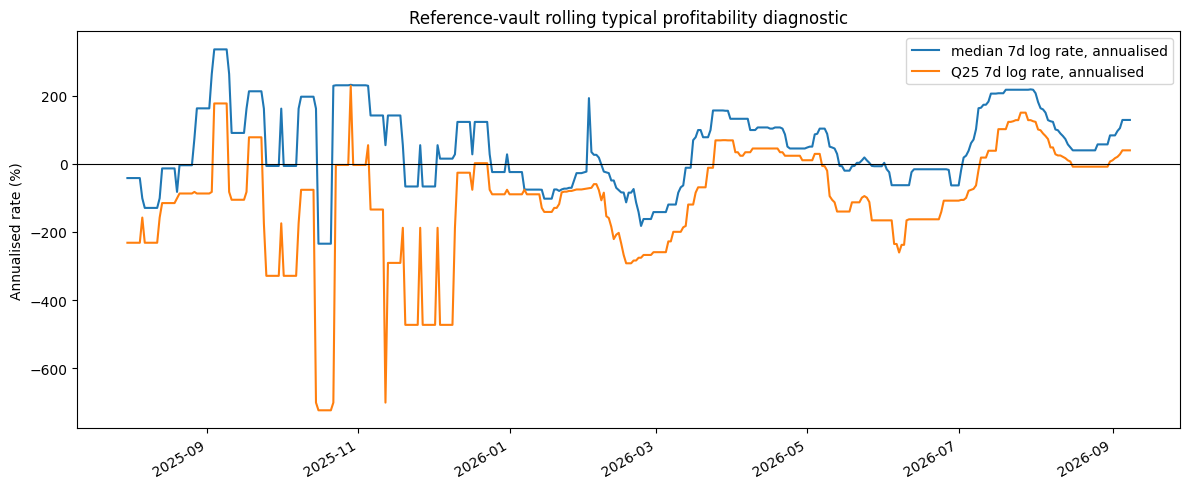

Saved artefacts: 11


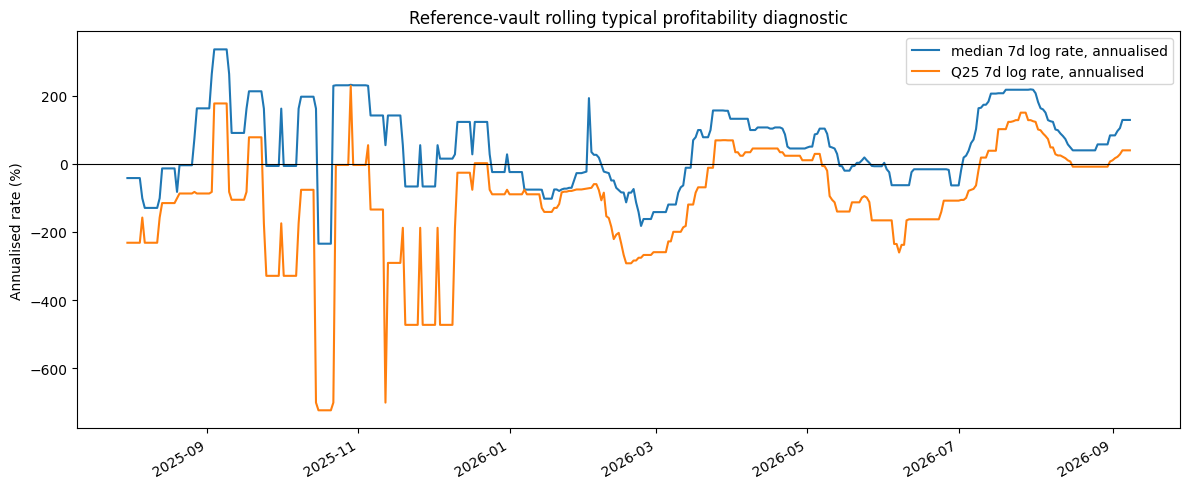

In [7]:
cohort_rows = []
for h, w in SPECS:
    score_col = f"median_log_rate_{h}_{w}"
    for cohort_name, group in panel.loc[panel.opportunity].groupby(["age_cohort", "cadence"], dropna=False):
        for horizon in HORIZONS:
            target = f"forward_return_{horizon}"
            complete = group[[score_col, target]].dropna()
            rho = complete[score_col].corr(complete[target], method="spearman") if len(complete) >= 5 and complete[score_col].nunique() > 1 and complete[target].nunique() > 1 else np.nan
            cohort_rows.append({"horizon": h, "span": w, "age_cohort": cohort_name[0], "cadence": cohort_name[1], "target_horizon": horizon, "opportunity_rows": len(group), "feature_rows": int(group[score_col].notna().sum()), "labelled_rows": len(complete), "rho_return": rho})
cohorts = pd.DataFrame(cohort_rows)
cohorts.to_csv(OUT / "cohort-summary.csv", index=False)
display(cohorts)

plot_address = reference_addresses["Systemic L/S Grids"]
plot_data = panel.loc[panel.address.eq(plot_address)].sort_values("date")
fig, ax = plt.subplots(figsize=(12, 5))
if len(plot_data):
    ax.plot(plot_data.date, plot_data[f"median_log_rate_7_30"] * 365 * 100, label="median 7d log rate, annualised")
    ax.plot(plot_data.date, plot_data[f"lower_quartile_log_rate_7_30"] * 365 * 100, label="Q25 7d log rate, annualised")
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("Reference-vault rolling typical profitability diagnostic")
ax.set_ylabel("Annualised rate (%)")
ax.legend()
fig.autofmt_xdate()
fig.tight_layout()
fig.savefig(OUT / "reference-rolling-features.png", dpi=150)
display(fig)

summary_manifest = {
    "status": "executed_diagnostic",
    "notebook": NOTEBOOK_NAME,
    "plan": PLAN_NAME,
    "parent_experiment": "NB25 corrected rolling-track input snapshot",
    "mechanism_delta": "median and lower-quartile actual-span-normalised rolling log return, with separate drawdown path diagnostics",
    "why_not_duplicate": "Tests incremental information against the existing positive-window-share, growth, Sharpe-like and volatility comparators without a portfolio arm or new threshold search.",
    "settings": SPECS,
    "forward_horizons": HORIZONS,
    "source_hashes": source_hashes,
    "outputs": sorted(path.name for path in OUT.iterdir() if path.is_file()),
}
(OUT / "manifest.json").write_text(json.dumps(summary_manifest, indent=2, default=str))
print("Saved artefacts:", len(summary_manifest["outputs"]), flush=True)